# Trabajo Práctico 3 - Visión por Computadora

### Alumnos:
* BETTIG, Santiago Federico
* DIEGUEZ, Manuel

### Consigna
Encontrar el logotipo de la gaseosa dentro de las imágenes provistas a partir del template

In [2]:
# Importamos las bibliotecas que vamos a utilizar
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
import os
import supervision as sv

#### Parte 1
Obtener una detección del logo en cada imagen sin falsos positivos

Ancho: 400 Alto: 175


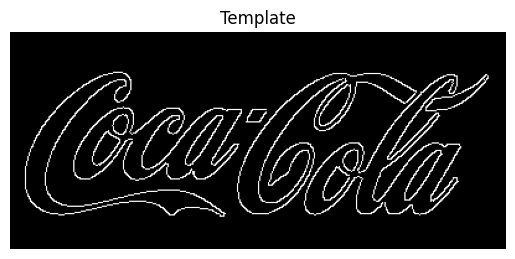

In [136]:
# Lo primero que hacemos es abrir nuestro template en 
# escala de grises
img_temp = cv.imread('template/pattern.png', cv.IMREAD_GRAYSCALE)
# img_temp = cv.bitwise_not(img_temp)
img_temp = cv.GaussianBlur(img_temp, (3,3), 0)   # reduce ruido antes de Canny
temp_edges = cv.Canny(img_temp, 50, 100)

# Nos aseguramos de que se haya abierto correctamente
plt.imshow(cv.cvtColor(temp_edges, cv.COLOR_BGR2RGB))
plt.title('Template')
plt.axis("off")

# Obtengo las dimensiones del template
w_temp, h_temp = img_temp.shape[::-1]

print(f"Ancho:", w_temp, "Alto:", h_temp)

(np.float64(-0.5), np.float64(1388.5), np.float64(1388.5), np.float64(-0.5))

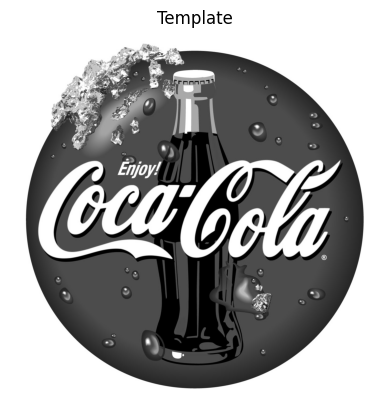

In [202]:
# Definimos la ruta en donde estarán las imágenes
img_path = './images/COCA-COLA-LOGO.jpg'
img_i = cv.imread(img_path)
img_gray = cv.imread(img_path, cv.IMREAD_GRAYSCALE)
# img_gray = cv.GaussianBlur(img_gray, (3,3), 0)
# img_edges = cv.Canny(img_gray, 160, 360)

# Nos aseguramos de que se haya abierto correctamente
plt.imshow(cv.cvtColor(img_gray, cv.COLOR_BGR2RGB))
plt.title('Template')
plt.axis("off")

In [203]:
PRINT_DEBUG_IMAGES = False

# Creo variables para guardar los mejores resultados de la exploración
best_score = -1
best_loc = None
best_r = None
r_count = 0
for r in np.linspace(0.2, 3.0, 80):
    resized_gray = cv.resize(img_gray, None, fx=r, fy=r, interpolation=cv.INTER_AREA if r < 1 else cv.INTER_LINEAR)
    r_count += 1
    # Si la imagen quedó mas chica que el template, no la comparo
    if resized_gray.shape[0] < h_temp or resized_gray.shape[1] < w_temp:
        continue  
    else:
        resized_gray = cv.GaussianBlur(resized_gray, (3,3), 0)
        resized_edges = cv.Canny(resized_gray, 160, 360)

        res = cv.matchTemplate(resized_edges, temp_edges, cv.TM_CCOEFF_NORMED)
        _, max_val, _, max_loc = cv.minMaxLoc(res)

        if PRINT_DEBUG_IMAGES:
            # Mapeo de vuelta a coordenadas de la imagen ORIGINAL (sin reescalar)
            top_left = (int(max_loc[0]/r), int(max_loc[1]/r))
            bottom_right = (int((max_loc[0]+w_temp)/r), int((max_loc[1]+h_temp)/r))
        
            img_rgb = cv.cvtColor(img_i, cv.COLOR_BGR2RGB)
            cv.rectangle(img_rgb, top_left, bottom_right, (0,255,0), 2)

            # Resultado de coincidencia
            plt.subplot(121),plt.imshow(resized_temp, cmap = 'gray')
            plt.title('Matching Result'), plt.xticks([]), plt.yticks([])
            # Imagen original con recuadros
            plt.subplot(122),plt.imshow(img_rgb)
            plt.title('Detected Point'), plt.xticks([]), plt.yticks([])
            plt.show()
            print(f"run: [",r_count,"]: ", max_val)

        if max_val > best_score:
            best_score, best_loc, best_r = max_val, max_loc, r

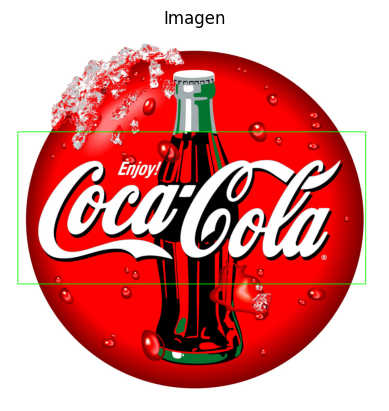

In [204]:
# Mapeo de vuelta a coordenadas de la imagen ORIGINAL (sin reescalar)
top_left = (int(best_loc[0]/best_r), int(best_loc[1]/best_r))
bottom_right = (int((best_loc[0]+w_temp)/best_r), int((best_loc[1]+h_temp)/best_r))

# # Marcamos el lugar donde lo haya encontrado
# bottom_right = (top_left[0] + int(w_temp*best_scale), top_left[1] + int(h_temp*best_scale))

img_rgb = cv.cvtColor(img_i, cv.COLOR_BGR2RGB)
cv.rectangle(img_rgb, top_left, bottom_right, (0,255,0), 2)

plt.figure()
plt.imshow(img_rgb)
plt.title('Imagen')
plt.axis("off");